# Transient Temperature Simulation in a Closed District Heating Grid

This example demonstrates a transient temperature simulation of a simple closed district heating network with pandapipes.

The network consists of:

- one circulation pump,
- one heat consumer,
- two pipes,
- and four junctions forming a closed loop.

The goal of this example is to show how the temperature propagates through the network over time and how the system slowly approaches a stationary thermal state.

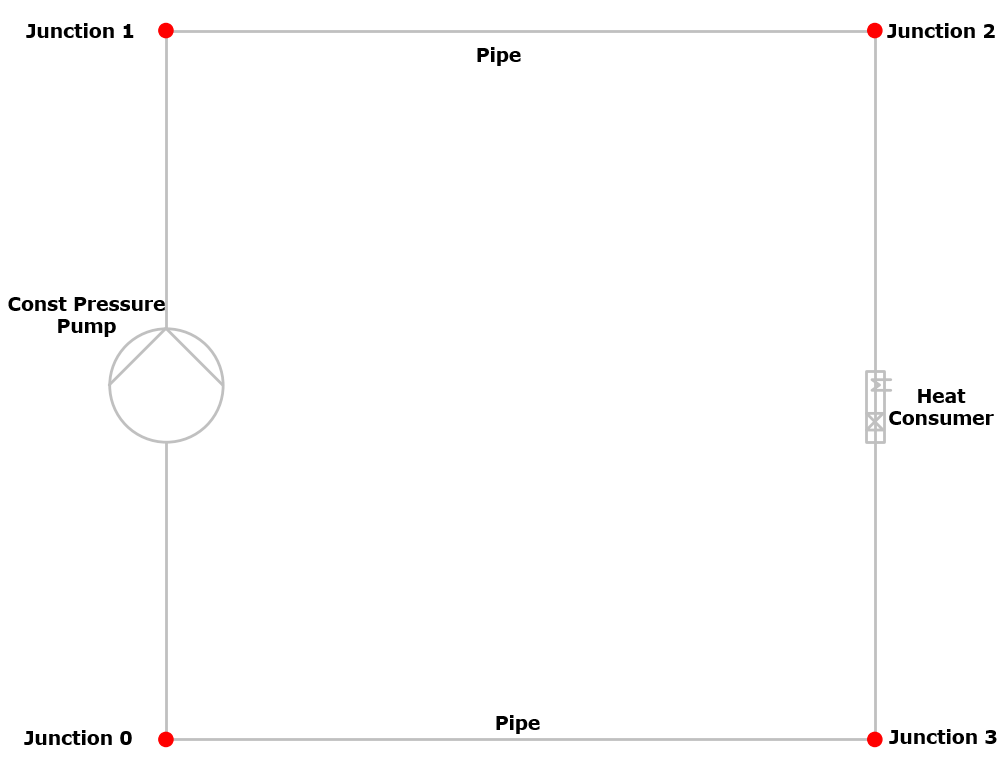

# Network Setup

First, pandapipes and the required libraries are imported.

In [101]:
import pandapipes as pp
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from matplotlib.collections import LineCollection
from pandapipes.component_models import Pipe
from pandapipes.idx_node import PINIT
from pandapipes.idx_branch import MDOTINIT

An empty network with water as working fluid is created.

In [102]:
net = pp.create_empty_network(fluid="water")

The pipes are created with a predefined standard type. The ambient temperature is set with text_k and is used for the heat loss calculation.

# Junctions

Four junctions are created.
Initially, the complete network starts with a temperature of 20 °C.

In [103]:
j0 = pp.create_junction(net, pn_bar=4, tfluid_k=293.15, name="junction 0", geodata=(0, 0))
j1 = pp.create_junction(net, pn_bar=4, tfluid_k=293.15, name="junction 1", geodata=(0, 10))
j2 = pp.create_junction(net, pn_bar=4, tfluid_k=293.15, name="junction 2", geodata=(10, 10))
j3 = pp.create_junction(net, pn_bar=4, tfluid_k=293.15, name="junction 3", geodata=(10, 0))

# Circulation Pump

The circulation pump continuously feeds hot water with a supply temperature of 70 °C into the network.

In [104]:
pp.create_circ_pump_const_pressure(
    net,
    return_junction=j0,
    flow_junction=j1,
    p_flow_bar=4,
    plift_bar=1.5,
    t_flow_k=273.15 + 70,
    type="auto",
    name="const_pressure_pump"
)

np.int64(0)

# Heat Consumer

A heat consumer extracts thermal energy from the network.

In [105]:
pp.create_heat_consumer(
    net,
    from_junction=j2,
    to_junction=j3,
    qext_w=167000,
    controlled_mdot_kg_per_s=2,
    deltat_k=None,
    treturn_k=None,
    type="heat_consumer"
)

np.int64(0)

The consumer removes a constant heat flow of 167 kW from the water.
This creates a temperature drop between the supply and return line, meaning that the water temperature decreases by approximately 20 °C.

# Pipes

Two pipes are used to form the closed loop.

In [106]:
pp.create_pipe(net, from_junction=j1, to_junction=j2, std_type="ISOPLUS_DRE100_STD", length_km=1, k_mm=0.1, loss_coefficient=0, sections=10, text_k=273.15 + 10, qext_w=0., name="pipe_0_1", type="pipe")

pp.create_pipe(net, from_junction=j3, to_junction=j0, std_type="ISOPLUS_DRE100_STD", length_km=1, k_mm=0.1, loss_coefficient=0, sections=10, text_k=273.15 + 10, qext_w=0., name="pipe_1_2", type="pipe")

np.int64(1)

The parameter sections=10 is important for the transient simulation.
Each pipe is internally discretized into multiple sections, which allows pandapipes to resolve the temperature distribution along the pipe length.

# Hydraulic Calculation

Before the transient simulation starts, the hydraulic state of the network is calculated.

In [107]:
pp.pipeflow(net, stop_condition="tol", iter=100, friction_model="colebrook", mode="hydraulics",transient=False,
    nonlinear_method="automatic", tol_p=1e-4, tol_m=1e-4)

Afterwards, the hydraulic solution is stored.

In [108]:
sol_vec = np.r_[
    net["_pit"]["node"][:, PINIT],
    net["_pit"]["branch"][:, MDOTINIT]
]

The hydraulic conditions remain constant during the transient thermal simulation.

# Initial Temperature Conditions

The network is initialized with a uniform temperature of 20 °C.

In [109]:
net.junction.loc[:, "tfluid_k"] = 273.15 + 20
net.junction.loc[:, "told_k"] = 273.15 + 20

## Visualization Function

In [116]:
# Uncomment plt.show() if you want to display the figure interactively.
def plot_temperature_snapshot(net, time_s):

    cmap = plt.cm.coolwarm
    norm = mcolors.Normalize(293.15, 343.15)

    coords = {
        0: (0, 0),
        1: (0, 1),
        2: (1, 1),
        3: (1, 0)
    }

    fig, ax = plt.subplots(figsize=(6, 5))

    for p, row in net.pipe.iterrows():

        fj = row.from_junction
        tj = row.to_junction

        pipe_results = Pipe.get_internal_results(net, [p])
        t_int = pipe_results["TINIT"]

        if t_int.ndim == 2:
            t_int = t_int[:, 1]

        temps = np.r_[
            net.res_junction.at[fj, "t_k"],
            t_int,
            net.res_junction.at[tj, "t_k"]
        ]

        xs = np.linspace(coords[fj][0], coords[tj][0], len(temps))
        ys = np.linspace(coords[fj][1], coords[tj][1], len(temps))

        pts = np.c_[xs, ys].reshape(-1, 1, 2)
        segs = np.c_[pts[:-1], pts[1:]].reshape(-1, 2, 2)

        lc = LineCollection(segs, cmap=cmap, norm=norm, linewidth=4)
        lc.set_array((temps[:-1] + temps[1:]) / 2)

        ax.add_collection(lc)

        ax.scatter(xs, ys,
                   c=temps,
                   cmap=cmap,
                   norm=norm,
                   s=45,
                   zorder=3)

    ax.plot([0, 0], [0, 1], color="gray", linestyle="--", linewidth=2)
    ax.text(-0.12, 0.5, "Pump", rotation=90, va="center", fontsize=10)

    ax.plot([1, 1], [1, 0], color="gray", linestyle="--", linewidth=2)
    ax.text(0.88, 0.5, "Consumer", rotation=90, va="center", fontsize=10)

    fig.colorbar(
        plt.cm.ScalarMappable(cmap=cmap, norm=norm),
        ax=ax,
        label="Temperature [K]"
    )

    ax.set_title(f"Temperature distribution at t = {time_s} s")
    ax.set_aspect("equal")
    ax.axis("off")

    # plt.show()
    plt.close(fig)

# Transient Temperature Simulation

The transient temperature calculation is performed with a timestep of 60 seconds.

In [110]:
dt = 60
t_end = 54000

The simulation is executed inside a time loop.

In [114]:
for t in range(dt, t_end + dt, dt):

    pp.pipeflow(net, sol_vec=sol_vec, stop_condition="tol", iter=100,
                friction_model="colebrook", mode="heat",
                transient=True, dt=dt, simulation_time_step=t,
                ambient_temperature=273.15 + 10,
                nonlinear_method="automatic", tol_T=1e-3)


    if t in [60, 300, 6009000, 18000, 36000,  54000]:
        # Temperature visualization function is provided in the Appendix section below.
        plot_temperature_snapshot(net, t)


    # print(net.res_junction["t_k"])

    net.junction.loc[:, "told_k"] = net.res_junction["t_k"].values
    net.junction.loc[:, "tfluid_k"] = net.res_junction["t_k"].values

# Temperature Visualization

The following function can be used to visualize the temperature distribution inside the network, including the internal pipe sections.
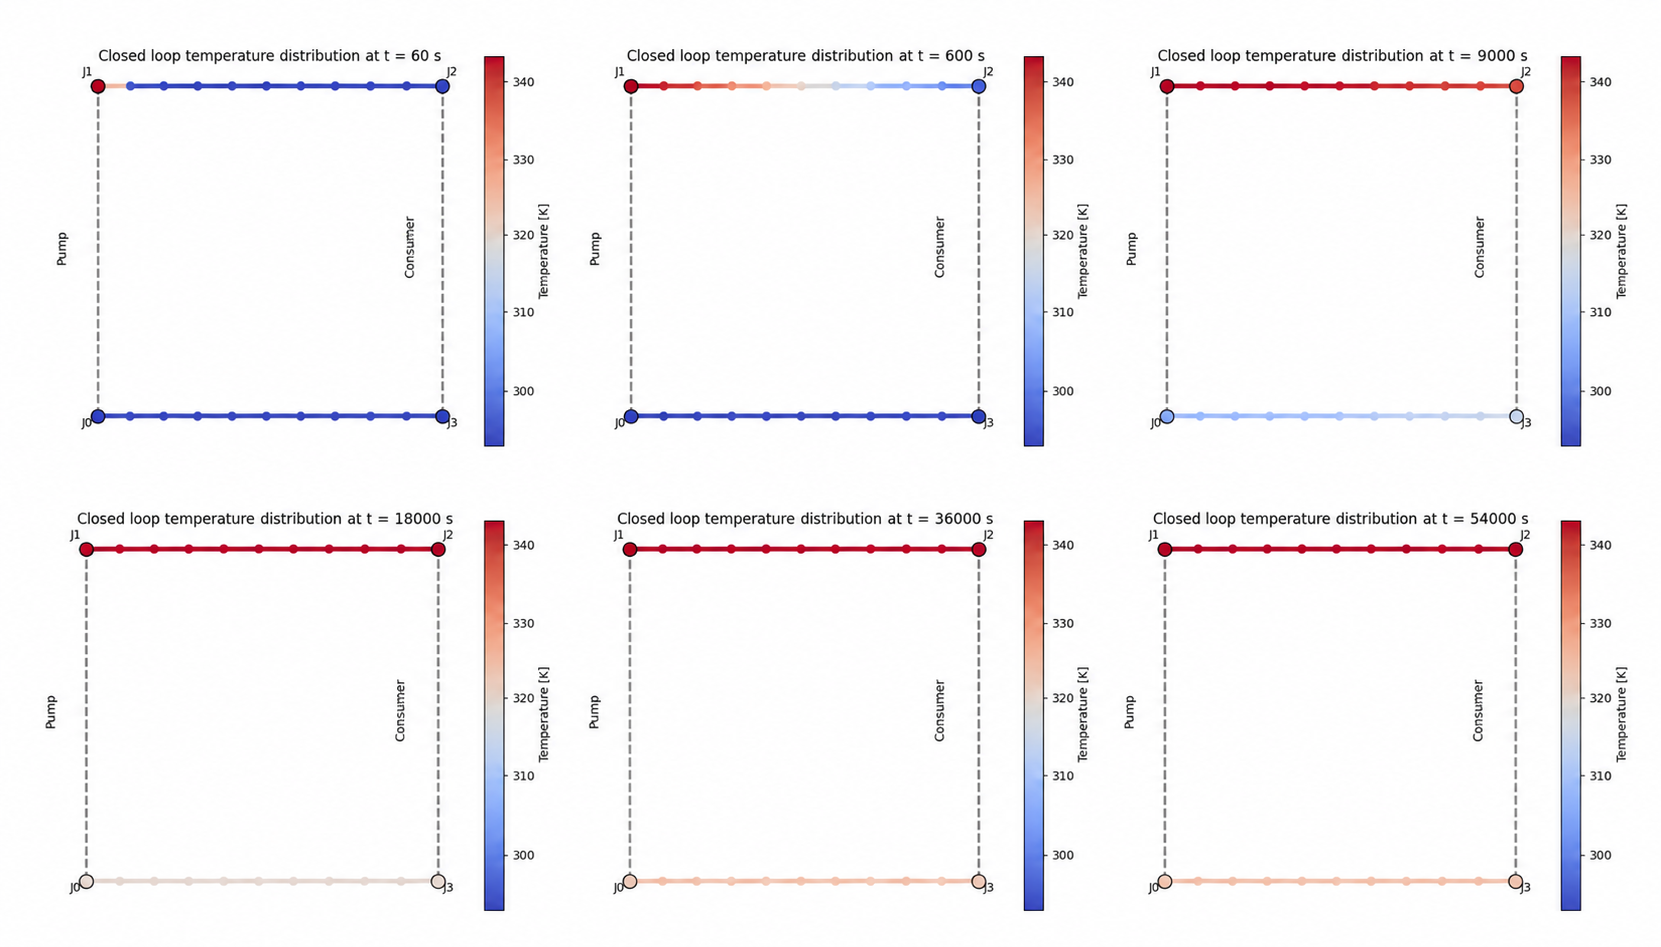

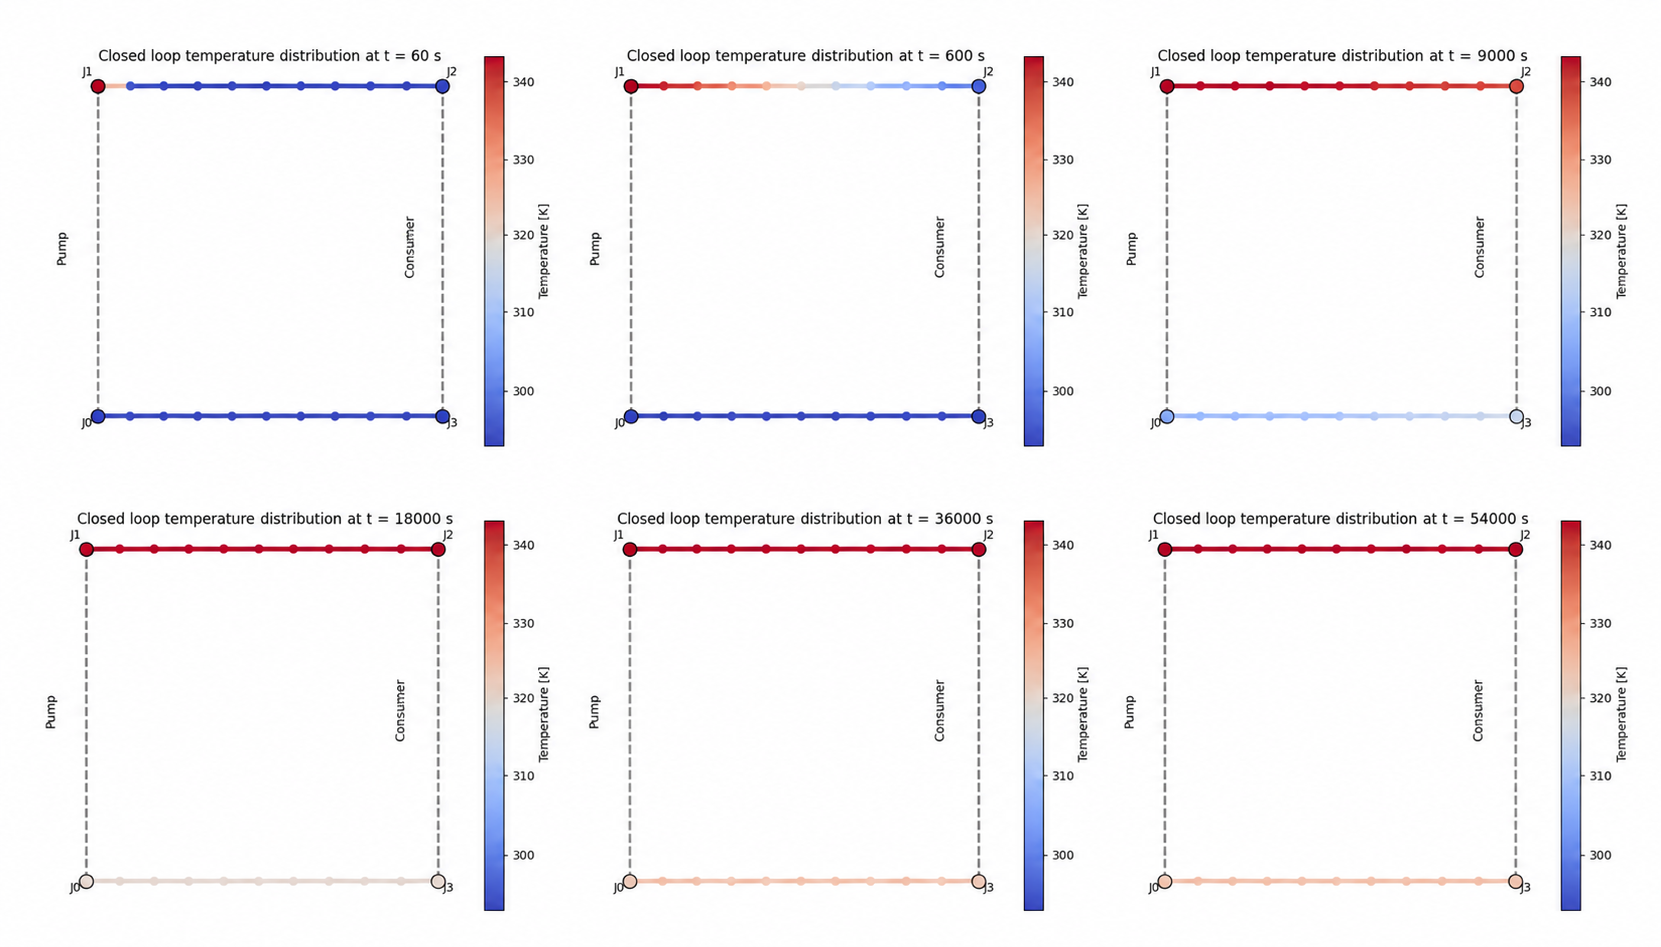

# Junction Temperatures During the Simulation
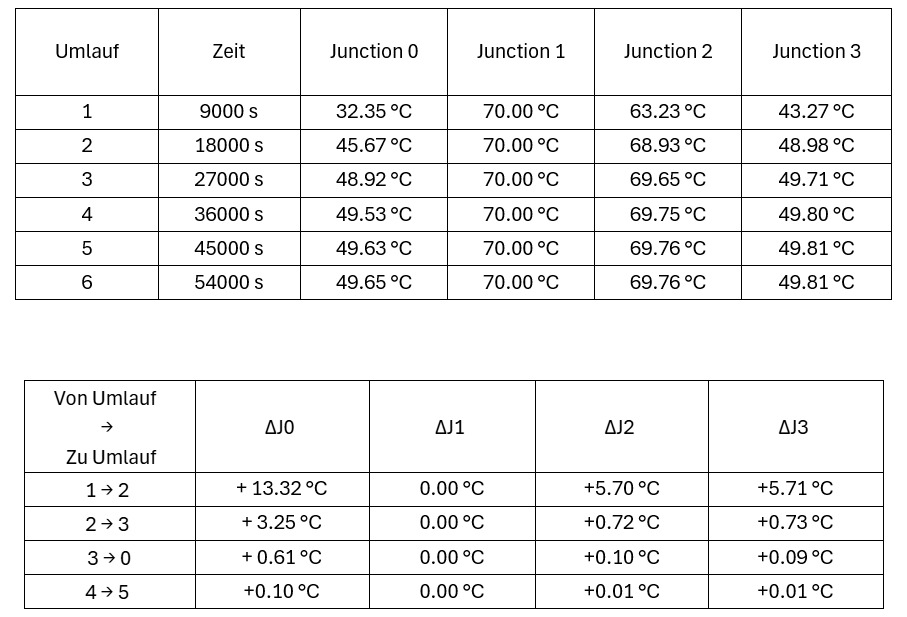
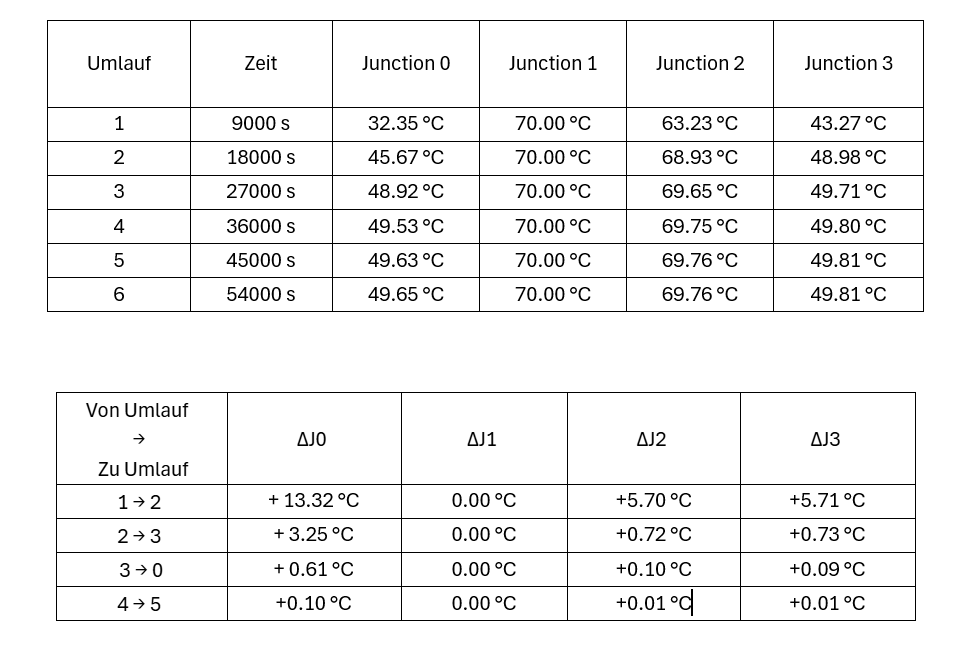
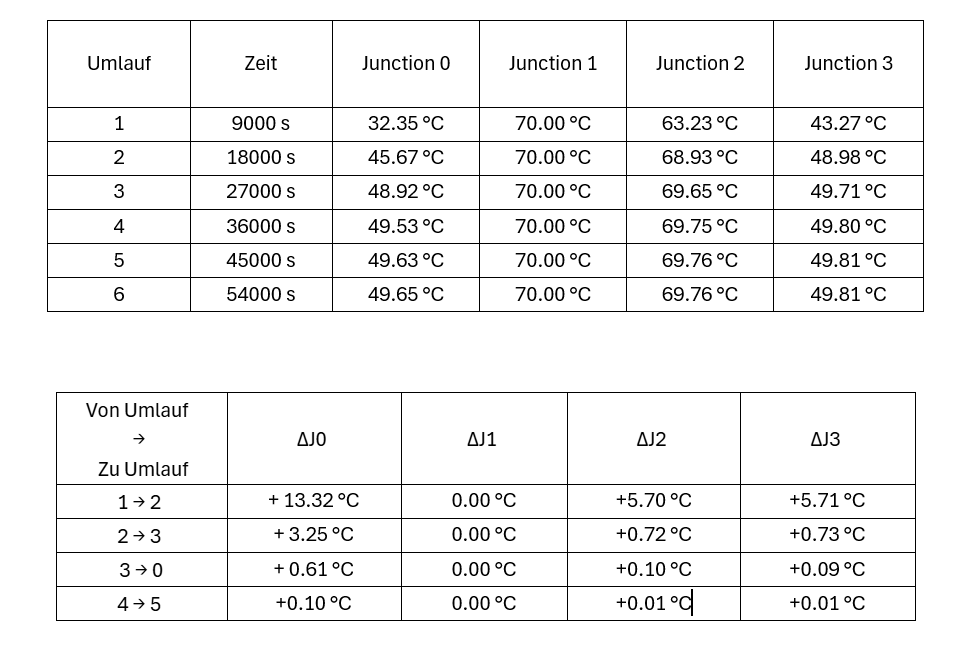
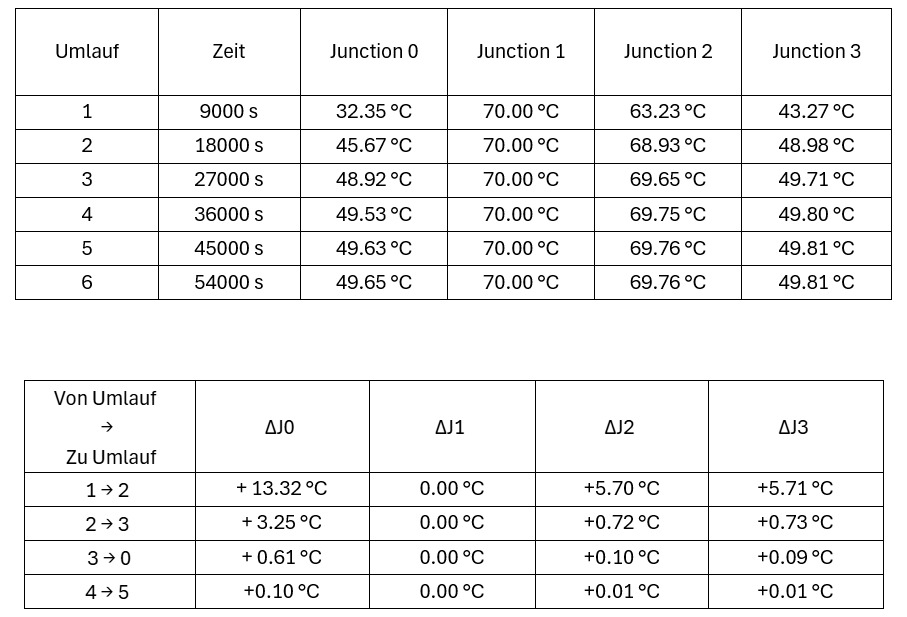

# Discussion

The results show a physically plausible qualitative behavior of the transient temperature propagation inside the closed district heating loop. The supply temperature at Junction 1 remains constant at 70 °C because the pump continuously injects hot water into the network.

The remaining junctions heat up gradually over time.
Especially the return line shows a delayed temperature increase because the initially cold water inside the network is slowly replaced by warmer water.

After several circulation cycles, the temperature changes become very small and the system approaches a stationary thermal equilibrium.
Therefore, the model does not represent a full thermo-hydraulic transient simulation with moving flow fronts or pressure wave propagation. Nevertheless, it is well suited for qualitative investigations of temperature propagation and thermal dynamics in district heating networks.

# Conclusion

This example demonstrates how transient thermal simulations can be performed in pandapipes for closed district heating networks.

The simulation shows:

gradual heating of the return line,
delayed temperature propagation,
and convergence towards a stationary thermal state.

Using pipe sections together with transient=True allows pandapipes to represent the spatial and temporal evolution of temperatures inside the network in a simple and efficient way.